# Population Demographics

A sanity check as much as a visualization: does the synthetic population
`scripts/generate_demo_data.py` produced actually look like a population, or
did a bug in the age/gender sampling logic slip through? An age-sex pyramid
is the standard way to look at a population's shape at a glance.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, "..")
sys.path.insert(0, ".")
from src.config.settings import settings

# Jupyter's kernel CWD is this notebook's own folder, but settings.duckdb_path
# defaults to a path relative to CWD — left alone, that resolves to
# notebooks/data/... and every query below would silently open a fresh,
# empty database instead of the real one at the repo root.
settings.duckdb_path = Path("../data/processed/omop_demo.duckdb")
import pandas as pd
from sqlalchemy import create_engine, text

from src.config.settings import settings

engine = create_engine(settings.database_url)
with engine.connect() as conn:
    person = pd.read_sql(text("SELECT gender_concept_id, year_of_birth FROM cdm.person"), conn)

REFERENCE_YEAR = 2026
person["age"] = REFERENCE_YEAR - person["year_of_birth"]
print(f"{len(person):,} patients, ages {person['age'].min()}-{person['age'].max()}")
engine.dispose()


3,000 patients, ages 1-101


Saved docs/assets/visualizations/population_pyramid.svg and population_pyramid.png


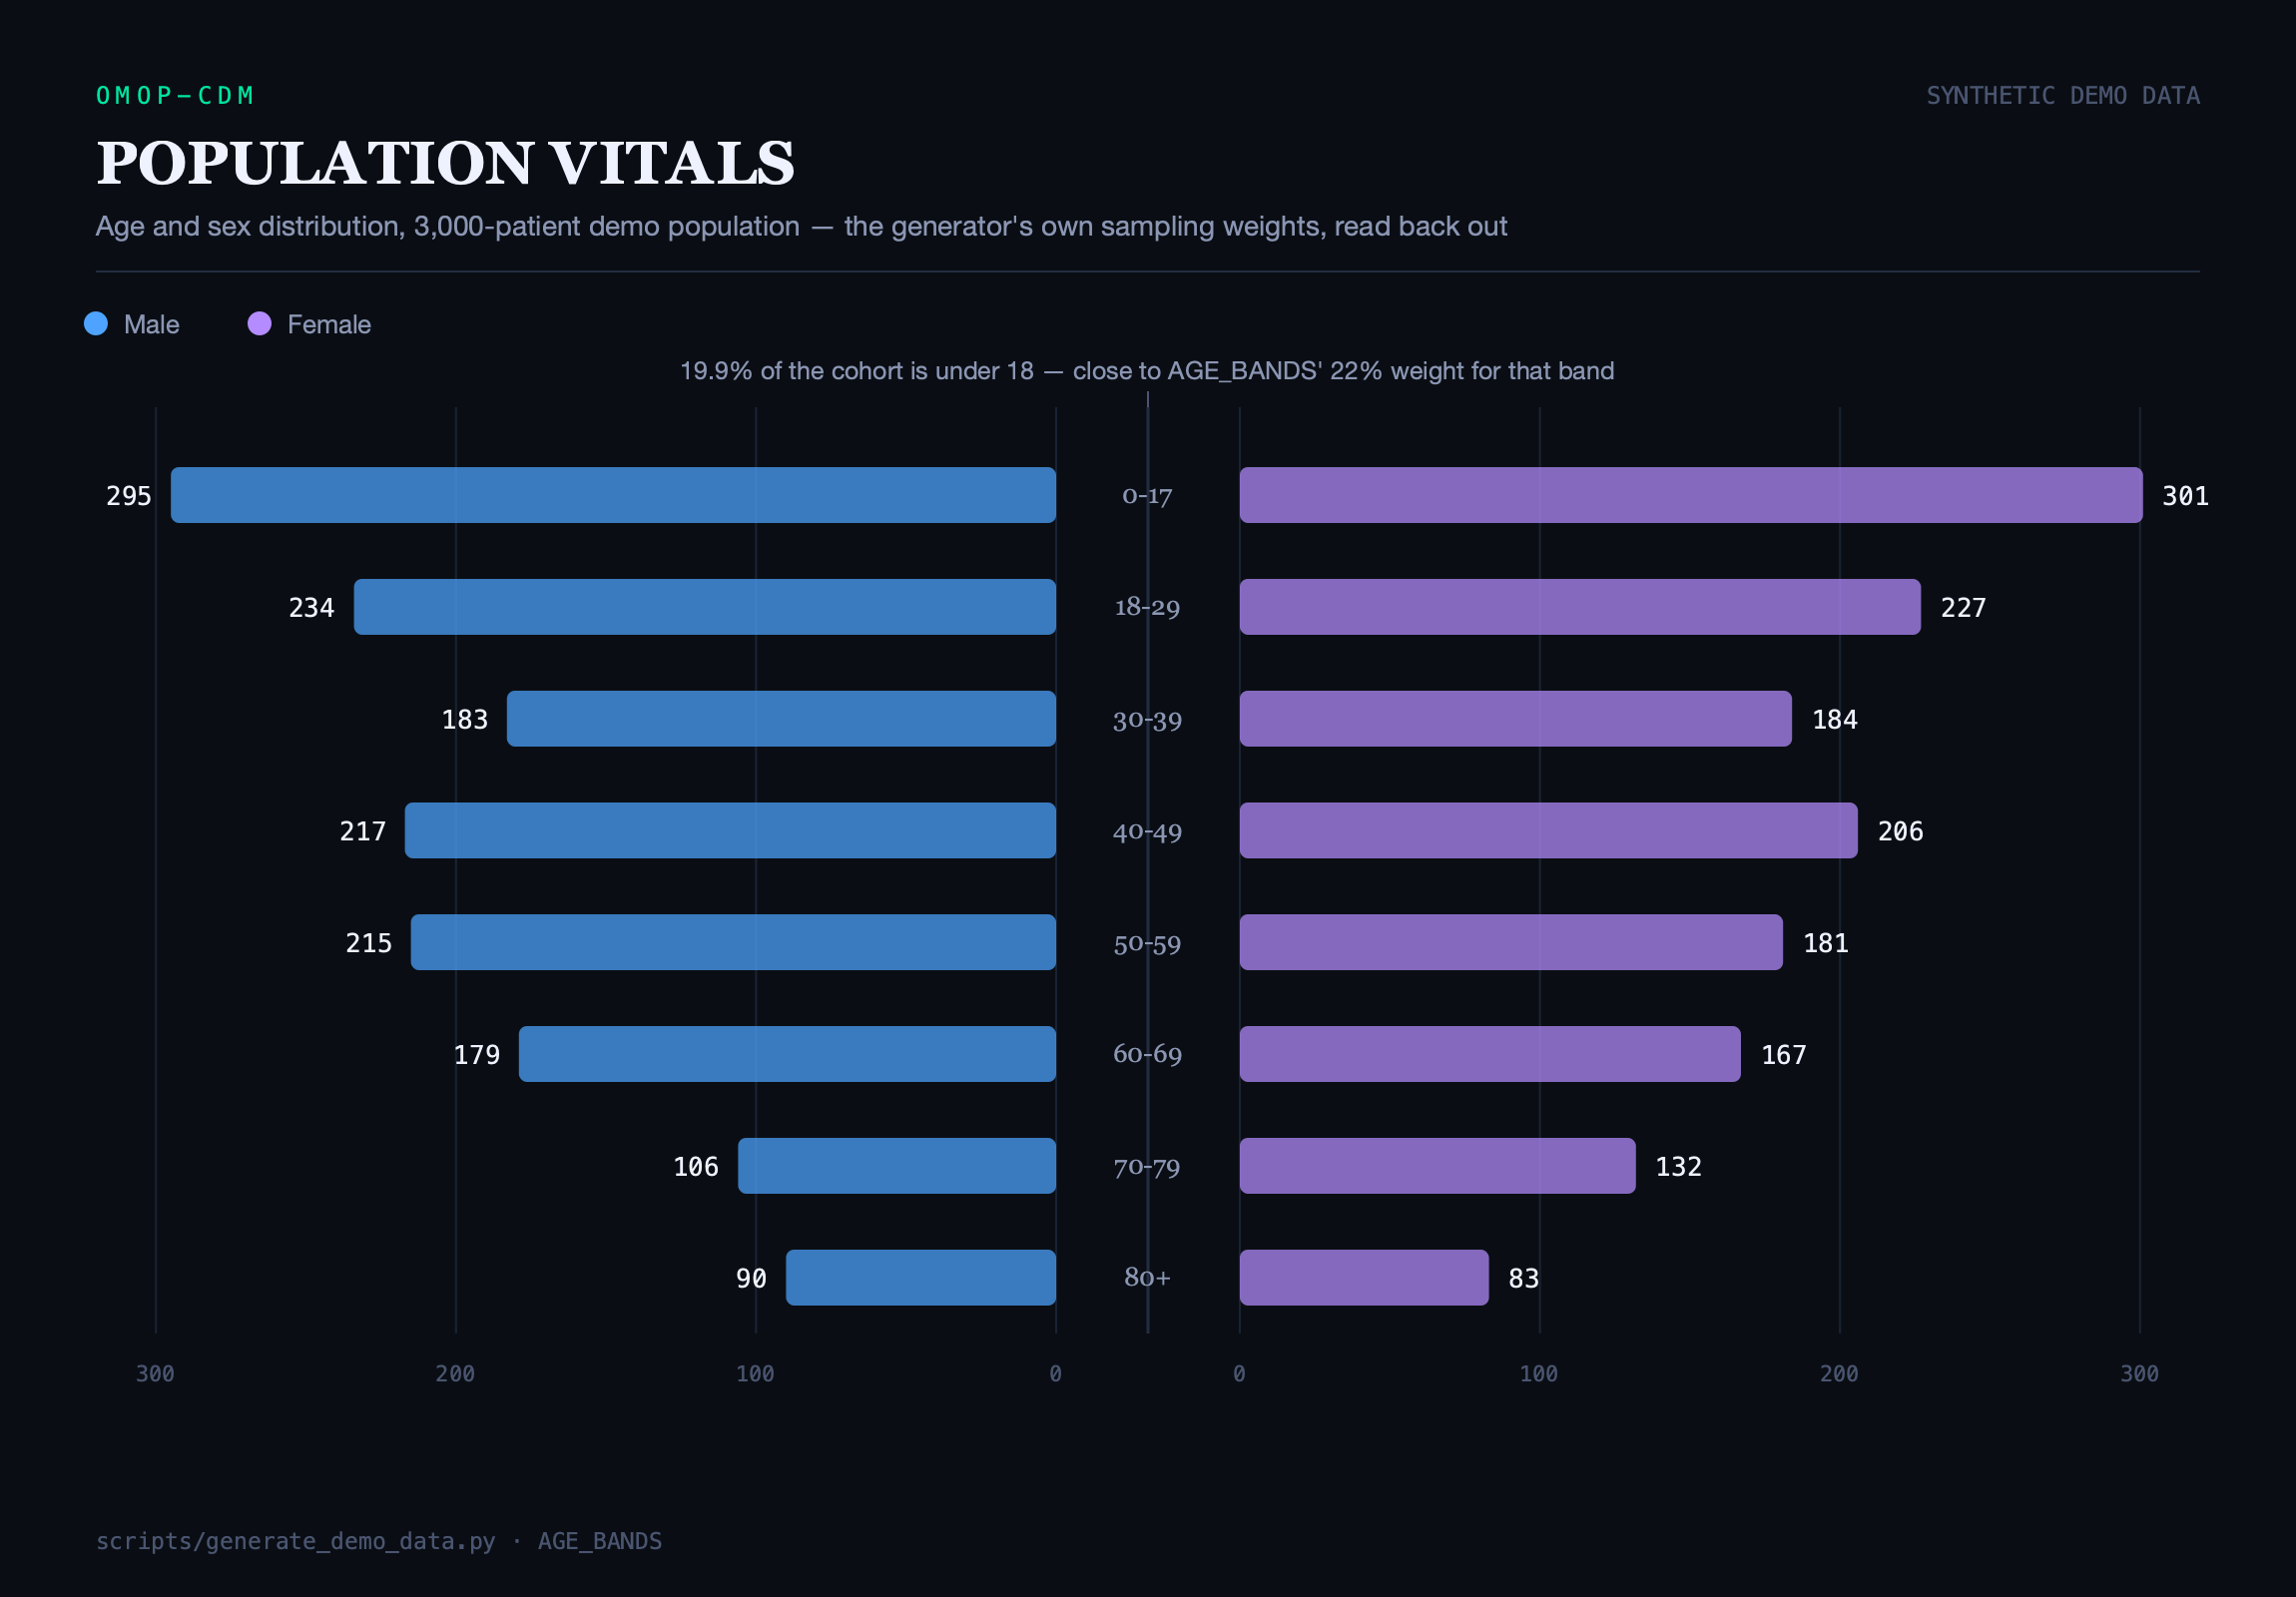

In [2]:
import subprocess
import sys
from IPython.display import Image

subprocess.run([sys.executable, "notebooks/build_population_pyramid.py"], cwd="..", check=True)
Image(filename="../docs/assets/visualizations/population_pyramid.png")


## Reading this

Roughly balanced by sex within every age band, and close to the age-band
sampling weights in `generate_demo_data.py`'s `AGE_BANDS` constant (22%
under-18 targeted, 19.9% realized in this 3,000-patient draw — sampling
variance, not a bug). That match is the point: this chart is what confirms
the generator's demographic sampling did what it was supposed to, not just
that it ran without errors. It's called out directly on the chart itself
rather than left for the reader to notice on their own.
